# Simplified Listener Pipeline
Loads the listener dataset, drops obvious non-feature columns, saves `clean_data.csv`, trains XGBoost and CatBoost once using best params from `best_results.csv`, runs across non-graph, graph-only, and combined feature sets, and shows feature importance plus SHAP for the best model. Only the target uses a log transform; features stay on their original scale.

In [34]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path
pd.set_option('display.max_columns', None)

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

sns.set_theme(style="ticks", palette="deep")
RANDOM_STATE = 42

DATA_PATH = Path("../data/final_df.csv")
TARGET = "followers"

CATEGORICAL_COLS = [
    "primary_label",
    "primary_genre",
    "primary_role",
    "artist_country",
    "artist_region_city",
]

BASE_FEATURES = [
    'releases_total', 'releases_per_year', 'avg_days_between_releases',
    'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
    'max_dry_spell_days', 'front_loading_index', 'tracks_total',
    'label_diversity_count', 'label_churn',
    'label_hhi', 'primary_label', 'duration_ms_mean', 'duration_ms_median',
    'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate',
    'genre_count', 'genre_entropy', 'primary_genre', 'artist_country',
    'artist_region_city', 'years_active', 'primary_role'
]

GRAPH_FEATURES = [
    'clust_local',
    'triangles', 'open_wedges', 'gwesp_score', 'degree', 'log_degree',
    'eigencent', 'kcore', 'betweenness', 'closeness', 'dist_to_hub_min',
    'same_genre_share', 'same_label_share', 'same_role_share',
    'tri_within_genre', 'tri_within_label', 'tri_within_role',
    'tri_cross_genre', 'tri_cross_label', 'tri_cross_role',
    'component_size', 'open_dyads', 'weak_tie_frac',
    'community_participation', 'collab_track_rate'
]

NODE2VEC_FEATURES = [
    'n2v_0', 'n2v_1', 'n2v_2', 'n2v_3', 'n2v_4',
    'n2v_5', 'n2v_6', 'n2v_7', 'n2v_8', 'n2v_9', 'n2v_10', 'n2v_11',
    'n2v_12', 'n2v_13', 'n2v_14', 'n2v_15'
]
MISSING_THRESHOLD = 0.30

if not DATA_PATH.exists():
    raise FileNotFoundError(f"CSV not found at {DATA_PATH.resolve()}")


## Load raw data

In [35]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns from {DATA_PATH.name}")
display(raw_df.head())


Loaded 86,843 rows and 68 columns from final_df.csv


,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_year,gap_median_days,gap_std_days,max_dry_spell_days,front_loading_index,tracks_total,collab_track_rate,label_diversity_count,label_churn,label_hhi,primary_label,duration_ms_mean,duration_ms_median,duration_ms_min,duration_ms_max,remix_rate,acoustic_rate,genre_count,genre_entropy,primary_genre,artist_country,artist_region_city,years_active,primary_role,clust_local,triangles,open_wedges,gwesp_score,degree,log_degree,eigencent,kcore,betweenness,closeness,dist_to_hub_min,same_genre_share,same_label_share,same_role_share,tri_within_genre,tri_within_label,tri_within_role,tri_cross_genre,tri_cross_label,tri_cross_role,component_size,open_dyads,weak_tie_frac,community_participation,n2v_0,n2v_1,n2v_2,n2v_3,n2v_4,n2v_5,n2v_6,n2v_7,n2v_8,n2v_9,n2v_10,n2v_11,n2v_12,n2v_13,n2v_14,n2v_15,followers
0,1,0.200027,NaN,NaN,NaN,NaN,NaN,1.000000,6,0.000000,1,0,1.000000,RCA Victor Red Seal,249275.500000,257000.0,80000.0,393653.0,0.000000,0.0,0,NaN,NaN,United States,Chicago,88.917180,arranger,0.054435,27.0,469.0,12.396268,32.0,3.496508,1.587213e-03,26.0,0.000012,0.249735,2.0,0.875000,0.000000,0.218750,21.0,0.0,2.0,0.0,22.0,3.0,223031.0,6858.0,0.625000,0.03125,1.803360,0.284715,-2.570527,-0.979614,0.759175,-0.082880,1.237425,-0.068748,0.308921,0.522858,-1.490200,-1.035179,-0.029398,-0.885130,-1.608004,-0.029887,1370.0
1,63,12.594828,28.274194,21.868353,0.0,105.789378,792.0,0.047619,63,0.269841,16,27,0.234568,Columbia Records,167655.661290,173800.0,100000.0,174906.0,0.000000,0.0,2,0.693147,pop,Italy,Città di Castello,62.086242,composer,0.226316,43.0,147.0,14.098771,20.0,3.044522,1.622286e-04,15.0,0.000010,0.243299,2.0,0.050000,0.050000,0.200000,0.0,0.0,0.0,0.0,27.0,19.0,223031.0,1236.0,0.300000,0.25000,-0.478827,0.056176,-0.510266,0.100374,0.218459,0.171027,0.418762,-1.228050,0.497059,-1.130705,0.855863,-1.110985,-0.723280,-1.215328,-1.375432,-0.266841,556472.0
2,4,0.800110,432.666667,0.650024,123.0,503.653541,1143.0,0.250000,7,1.000000,1,0,1.000000,West One Music,207631.285714,214000.0,79061.0,279000.0,0.000000,0.0,0,NaN,NaN,London,NaN,11.507187,composer,1.000000,3.0,0.0,1.896362,3.0,1.386294,3.260441e-12,3.0,0.000000,0.131257,6.0,1.000000,1.000000,0.666667,3.0,3.0,1.0,0.0,0.0,0.0,223031.0,7.0,0.000000,0.00000,1.007928,0.698243,-0.681591,-0.043474,0.892301,0.392488,1.018558,-0.351849,-0.664887,1.655548,-0.704499,1.116690,-0.311980,-1.163549,-1.416427,-0.979821,5.0
3,1,0.199918,NaN,NaN,NaN,NaN,NaN,1.000000,1,1.000000,1,0,1.000000,New State Music,247600.000000,247600.0,247600.0,247600.0,0.000000,0.0,0,NaN,NaN,United Kingdom,NaN,14.165640,unknown,1.000000,1.0,0.0,0.786939,2.0,1.098612,1.161562e-35,2.0,0.000000,0.000000,inf,1.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.000000,0.00000,0.155933,-0.297782,0.295990,-1.379524,1.363095,0.421061,1.616979,0.371881,1.033139,0.388670,-0.368274,-0.680233,0.311329,-0.001594,-2.238091,0.134448,294.0
4,52,14.443346,23.411765,16.307140,11.0,31.101464,118.0,0.692308,84,0.666667,16,22,0.161243,Lofi Records,146776.095238,136721.0,100500.0,231000.0,0.095238,0.0,8,2.079442,boom bap,London,NaN,3.600274,composer,0.110924,66.0,529.0,27.427670,35.0,3.583519,1.072141e-05,14.0,0.000065,0.206836,2.0,0.457143,0.171429,0.400000,10.0,1.0,5.0,2.0,37.0,15.0,223031.0,707.0,0.085714,0.00000,0.735377,0.244508,-2.646595,-0.916907,1.123754,1.120741,0.981917,-1.506794,-0.650203,-0.086935,0.116487,1.936875,0.313060,-2.675613,-1.462313,-0.050917,2916.0


Top 1% follower threshold: 6003109.600000007


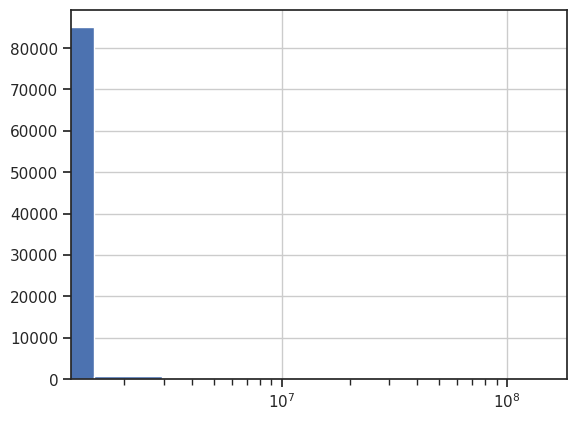

In [36]:
threshold = raw_df[TARGET].quantile(0.995)
print("Top 1% follower threshold:", threshold)
raw_df[TARGET].describe()
raw_df[TARGET].hist(bins=100)
plt.xscale("log")


## Clean columns and save clean_data.csv

In [37]:
df = raw_df.copy()

threshold = df[TARGET].quantile(0.995)
df = df[df[TARGET] <= threshold].copy()

cat_cols = [c for c in CATEGORICAL_COLS if c in df.columns]
for col in cat_cols:
    df[col] = df[col].fillna('unknown')
    df[col] = df[col].astype("category")

if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' not found after dropping columns")

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df[TARGET] += 1
df = df.dropna(subset=[TARGET])

numeric_cols = [c for c in df.columns if c not in cat_cols + [TARGET]]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")


missing_rate = df.isna().mean()
high_missing = missing_rate[missing_rate > MISSING_THRESHOLD].index.tolist()
if high_missing:
    print(f"Dropping columns with >{int(MISSING_THRESHOLD*100)}% missing: {high_missing}")
    df = df.drop(columns=high_missing)
    cat_cols = [c for c in cat_cols if c not in high_missing]
    numeric_cols = [c for c in numeric_cols if c not in high_missing]

# Replace inf/-inf with NaN (models handle NaN directly)
df = df.replace([np.inf, -np.inf], np.nan)

clean_path = Path("clean_data.csv")
df.to_csv(clean_path, index=False)
print(f"Cleaned data shape: {df.shape}, saved to {clean_path}")
display(df.head())


Dropping columns with >30% missing: ['genre_entropy']
Cleaned data shape: (86297, 67), saved to clean_data.csv


,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_year,gap_median_days,gap_std_days,max_dry_spell_days,front_loading_index,tracks_total,collab_track_rate,label_diversity_count,label_churn,label_hhi,primary_label,duration_ms_mean,duration_ms_median,duration_ms_min,duration_ms_max,remix_rate,acoustic_rate,genre_count,primary_genre,artist_country,artist_region_city,years_active,primary_role,clust_local,triangles,open_wedges,gwesp_score,degree,log_degree,eigencent,kcore,betweenness,closeness,dist_to_hub_min,same_genre_share,same_label_share,same_role_share,tri_within_genre,tri_within_label,tri_within_role,tri_cross_genre,tri_cross_label,tri_cross_role,component_size,open_dyads,weak_tie_frac,community_participation,n2v_0,n2v_1,n2v_2,n2v_3,n2v_4,n2v_5,n2v_6,n2v_7,n2v_8,n2v_9,n2v_10,n2v_11,n2v_12,n2v_13,n2v_14,n2v_15,followers
0,1,0.200027,NaN,NaN,NaN,NaN,NaN,1.000000,6,0.000000,1,0,1.000000,RCA Victor Red Seal,249275.500000,257000.0,80000.0,393653.0,0.000000,0.0,0,unknown,United States,Chicago,88.917180,arranger,0.054435,27.0,469.0,12.396268,32.0,3.496508,1.587213e-03,26.0,0.000012,0.249735,2.0,0.875000,0.000000,0.218750,21.0,0.0,2.0,0.0,22.0,3.0,223031.0,6858.0,0.625000,0.03125,1.803360,0.284715,-2.570527,-0.979614,0.759175,-0.082880,1.237425,-0.068748,0.308921,0.522858,-1.490200,-1.035179,-0.029398,-0.885130,-1.608004,-0.029887,1371.0
1,63,12.594828,28.274194,21.868353,0.0,105.789378,792.0,0.047619,63,0.269841,16,27,0.234568,Columbia Records,167655.661290,173800.0,100000.0,174906.0,0.000000,0.0,2,pop,Italy,Città di Castello,62.086242,composer,0.226316,43.0,147.0,14.098771,20.0,3.044522,1.622286e-04,15.0,0.000010,0.243299,2.0,0.050000,0.050000,0.200000,0.0,0.0,0.0,0.0,27.0,19.0,223031.0,1236.0,0.300000,0.25000,-0.478827,0.056176,-0.510266,0.100374,0.218459,0.171027,0.418762,-1.228050,0.497059,-1.130705,0.855863,-1.110985,-0.723280,-1.215328,-1.375432,-0.266841,556473.0
2,4,0.800110,432.666667,0.650024,123.0,503.653541,1143.0,0.250000,7,1.000000,1,0,1.000000,West One Music,207631.285714,214000.0,79061.0,279000.0,0.000000,0.0,0,unknown,London,unknown,11.507187,composer,1.000000,3.0,0.0,1.896362,3.0,1.386294,3.260441e-12,3.0,0.000000,0.131257,6.0,1.000000,1.000000,0.666667,3.0,3.0,1.0,0.0,0.0,0.0,223031.0,7.0,0.000000,0.00000,1.007928,0.698243,-0.681591,-0.043474,0.892301,0.392488,1.018558,-0.351849,-0.664887,1.655548,-0.704499,1.116690,-0.311980,-1.163549,-1.416427,-0.979821,6.0
3,1,0.199918,NaN,NaN,NaN,NaN,NaN,1.000000,1,1.000000,1,0,1.000000,New State Music,247600.000000,247600.0,247600.0,247600.0,0.000000,0.0,0,unknown,United Kingdom,unknown,14.165640,unknown,1.000000,1.0,0.0,0.786939,2.0,1.098612,1.161562e-35,2.0,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.000000,0.00000,0.155933,-0.297782,0.295990,-1.379524,1.363095,0.421061,1.616979,0.371881,1.033139,0.388670,-0.368274,-0.680233,0.311329,-0.001594,-2.238091,0.134448,295.0
4,52,14.443346,23.411765,16.307140,11.0,31.101464,118.0,0.692308,84,0.666667,16,22,0.161243,Lofi Records,146776.095238,136721.0,100500.0,231000.0,0.095238,0.0,8,boom bap,London,unknown,3.600274,composer,0.110924,66.0,529.0,27.427670,35.0,3.583519,1.072141e-05,14.0,0.000065,0.206836,2.0,0.457143,0.171429,0.400000,10.0,1.0,5.0,2.0,37.0,15.0,223031.0,707.0,0.085714,0.00000,0.735377,0.244508,-2.646595,-0.916907,1.123754,1.120741,0.981917,-1.506794,-0.650203,-0.086935,0.116487,1.936875,0.313060,-2.675613,-1.462313,-0.050917,2917.0


## Build feature sets (non-graph, graph-only, combined)

In [38]:
base_features = [f for f in BASE_FEATURES if f in df.columns]
graph_features = [f for f in GRAPH_FEATURES if f in df.columns]
n2v_features = [f for f in NODE2VEC_FEATURES if f in df.columns]

feature_sets = {
    "base": base_features,
    "graph": graph_features,
    "n2v": n2v_features,
    "base+graph": base_features + graph_features,   
    "base+n2v": base_features + n2v_features,
    "graph+n2v": graph_features + n2v_features,
    "base+graph+n2v": base_features + graph_features + n2v_features,
}

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")


base: 25 features
graph: 25 features
n2v: 16 features
base+graph: 50 features
base+n2v: 41 features
graph+n2v: 41 features
base+graph+n2v: 66 features


## Train/test split indices (shared across feature sets)

In [39]:
train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train rows: {len(train_idx)}, Test rows: {len(test_idx)}")


Train rows: 69037, Test rows: 17260


## Load best params and train XGBoost/CatBoost for each feature set

In [43]:
best_df = pd.read_csv("best_results.csv")


def load_best_params(model_name: str) -> dict:
    row = best_df.loc[best_df["model"] == model_name]
    if row.empty:
        raise ValueError(f"No params for {model_name} in best_results.csv")
    raw = ast.literal_eval(row.iloc[0]["best_params"])
    return {k.split("__")[-1]: v for k, v in raw.items()}


xgb_params = load_best_params("xgboost")
cat_params = load_best_params("catboost")


def encode_for_xgb(frame: pd.DataFrame, cat_subset):
    encoded = frame.copy()
    for col in cat_subset:
        cat = pd.Categorical(encoded[col])
        encoded[col] = pd.Series(cat.codes, index=encoded.index).replace(-1, np.nan)
    return encoded


def evaluate(model_name: str, model, X_eval: pd.DataFrame, y_true, y_true_log):
    preds_log = model.predict(X_eval)
    preds = np.expm1(preds_log)
    return {
        "model": model_name,
        "rmse": np.sqrt(mean_squared_error(y_true, preds)),
        "mae": mean_absolute_error(y_true, preds),
        "r2": r2_score(y_true, preds),
        "rmse_log": np.sqrt(mean_squared_error(y_true_log, preds_log)),
        "r2_log": r2_score(y_true_log, preds_log),
    }


def rmse_cv(estimator, X, y_true):
    preds = np.expm1(estimator.predict(X))
    return -np.sqrt(mean_squared_error(y_true, preds))


def r2_cv(estimator, X, y_true):
    preds = np.expm1(estimator.predict(X))
    return r2_score(y_true, preds)


results = []
trained = {}

for fs_name, cols in feature_sets.items():
    print(fs_name)
    if not cols:
        print(f"Skipping {fs_name} (no features).")
        continue

    X = df.loc[:, cols]
    y = df[TARGET].astype(float)

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    cat_cols_fs = [c for c in cat_cols if c in cols]
    cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

    X_train_xgb = encode_for_xgb(X_train, cat_cols_fs)
    X_test_xgb = encode_for_xgb(X_test, cat_cols_fs)

    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        tree_method="hist",
        enable_categorical=True,
        n_jobs=-1,
        **xgb_params,
    )

    cat_model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
        cat_features=cat_idx,
        **cat_params,
    )

    scorers = {"rmse": rmse_cv, "r2": r2_cv}

    cv_xgb = cross_validate(
        xgb_model,
        X_train_xgb,
        y_train_log,
        cv=5,
        scoring=scorers,
        n_jobs=1,
        error_score="raise",
    )
    cv_cat = cross_validate(
        cat_model,
        X_train,
        y_train_log,
        cv=5,
        scoring=scorers,
        n_jobs=1,
        error_score="raise",
    )

    xgb_model.fit(X_train_xgb, y_train_log)
    cat_model.fit(X_train, y_train_log)

    metrics = [
        evaluate("xgboost", xgb_model, X_test_xgb, y_test, y_test_log),
        evaluate("catboost", cat_model, X_test, y_test, y_test_log),
    ]

    metrics[0].update(
        {
            "cv_rmse_mean": -np.mean(cv_xgb["test_rmse"]),
            "cv_rmse_std": np.std(cv_xgb["test_rmse"]),
            "cv_r2_mean": np.mean(cv_xgb["test_r2"]),
            "cv_r2_std": np.std(cv_xgb["test_r2"]),
        }
    )
    metrics[1].update(
        {
            "cv_rmse_mean": -np.mean(cv_cat["test_rmse"]),
            "cv_rmse_std": np.std(cv_cat["test_rmse"]),
            "cv_r2_mean": np.mean(cv_cat["test_r2"]),
            "cv_r2_std": np.std(cv_cat["test_r2"]),
        }
    )

    for m in metrics:
        m["feature_set"] = fs_name
    results.extend(metrics)

    trained[(fs_name, "xgboost")] = {
        "model": xgb_model,
        "X_test": X_test_xgb,
        "feature_names": list(X_train_xgb.columns),
    }
    trained[(fs_name, "catboost")] = {
        "model": cat_model,
        "X_test": X_test,
        "feature_names": list(X_train.columns),
    }

results_df = pd.DataFrame(results).sort_values(["rmse", "rmse_log"]).reset_index(drop=True)
display(results_df)

best_row = results_df.iloc[0]
print(f"Best overall: {best_row['model']} on {best_row['feature_set']}")
best_key = (best_row["feature_set"], best_row["model"])
best_bundle = trained[best_key]
best_model = best_bundle["model"]
best_features = best_bundle["X_test"]
feature_names = best_bundle["feature_names"]


base
graph
n2v
base+graph
base+n2v
graph+n2v
base+graph+n2v


,model,rmse,mae,r2,rmse_log,r2_log,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,feature_set
0,catboost,396724.082922,86409.872305,0.042233,2.398728,0.417327,53111.725525,7663.334519,-2.944947e+08,9.043368e+07,base+graph+n2v
1,catboost,399477.235451,87293.887284,0.028893,2.431624,0.401236,51441.926919,6627.839685,-2.752895e+08,7.379451e+07,base+n2v
2,catboost,401052.235934,87322.962228,0.021221,2.451359,0.391477,42802.209118,4944.033020,-1.899422e+08,4.541216e+07,base+graph
3,catboost,403191.483744,88120.425481,0.010751,2.584021,0.323831,36302.317402,6639.998858,-1.394470e+08,5.333424e+07,graph+n2v
4,catboost,407915.811374,89402.400144,-0.012567,2.714202,0.253986,26240.577842,2863.323998,-7.127685e+07,1.648085e+07,graph
5,catboost,408847.364128,89237.118410,-0.017197,2.553835,0.339537,24289.159771,1376.016508,-6.049807e+07,6.452032e+06,base
6,catboost,409392.972339,90077.188296,-0.019914,2.693191,0.265491,19862.301451,2212.242168,-4.087104e+07,8.988094e+06,n2v
7,xgboost,413195.995312,90544.066476,-0.038951,2.699234,0.262191,6939.767059,163.164478,-4.930315e+06,2.530745e+05,base+graph+n2v
8,xgboost,413552.036765,90864.172376,-0.040742,2.785506,0.214274,6206.193710,193.170564,-3.944517e+06,2.558918e+05,graph+n2v
9,xgboost,413574.689604,90689.691761,-0.040856,2.738383,0.240634,6512.834950,141.403630,-4.341437e+06,1.982000e+05,base+graph


Best overall: catboost on base+graph+n2v


In [ ]:

# best_df = pd.read_csv("best_results.csv")


# def load_best_params(model_name: str) -> dict:
#     row = best_df.loc[best_df["model"] == model_name]
#     if row.empty:
#         raise ValueError(f"No params for {model_name} in best_results.csv")
#     raw = ast.literal_eval(row.iloc[0]["best_params"])
#     return {k.split("__")[-1]: v for k, v in raw.items()}


# # Only load CatBoost params now
# cat_params = load_best_params("catboost")


# def evaluate(model_name: str, model, X_eval: pd.DataFrame, y_true, y_true_log):
#     preds_log = model.predict(X_eval)
#     preds = np.expm1(preds_log)
#     return {
#         "model": model_name,
#         "rmse": np.sqrt(mean_squared_error(y_true, preds)),
#         "mae": mean_absolute_error(y_true, preds),
#         "r2": r2_score(y_true, preds),
#         "rmse_log": np.sqrt(mean_squared_error(y_true_log, preds_log)),
#         "r2_log": r2_score(y_true_log, preds_log),
#     }


# results = []
# trained = {}

# for fs_name, cols in feature_sets.items():
#     print(fs_name)
#     if not cols:
#         print(f"Skipping {fs_name} (no features).")
#         continue

#     X = df.loc[:, cols]
#     y = df[TARGET].astype(float)

#     X_train = X.loc[train_idx]
#     X_test = X.loc[test_idx]
#     y_train = y.loc[train_idx]
#     y_test = y.loc[test_idx]

#     cat_cols_fs = [c for c in cat_cols if c in cols]
#     cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

#     y_train_log = np.log1p(y_train)
#     y_test_log = np.log1p(y_test)

#     cat_model = CatBoostRegressor(
#         loss_function="RMSE",
#         random_seed=RANDOM_STATE,
#         verbose=0,
#         allow_writing_files=False,
#         cat_features=cat_idx,
#         **cat_params,
#     )

#     # Simple train / test (no cross-validation)
#     cat_model.fit(X_train, y_train_log)

#     metrics = evaluate("catboost", cat_model, X_test, y_test, y_test_log)
#     metrics["feature_set"] = fs_name
#     results.append(metrics)

#     trained[(fs_name, "catboost")] = {
#         "model": cat_model,
#         "X_test": X_test,
#         "feature_names": list(X_train.columns),
#     }

# results_df = (
#     pd.DataFrame(results)
#     .sort_values(["rmse", "rmse_log"])
#     .reset_index(drop=True)
# )
# display(results_df)

# best_row = results_df.iloc[0]
# print(f"Best overall: {best_row['model']} on {best_row['feature_set']}")
# best_key = (best_row["feature_set"], best_row["model"])
# best_bundle = trained[best_key]
# best_model = best_bundle["model"]
# best_features = best_bundle["X_test"]
# feature_names = best_bundle["feature_names"]

base


KeyboardInterrupt: 

In [ ]:
# def encode_for_xgb(frame: pd.DataFrame, cat_subset):
#     encoded = frame.copy()
#     for col in cat_subset:
#         cat = pd.Categorical(encoded[col])
#         encoded[col] = pd.Series(cat.codes, index=encoded.index).replace(-1, np.nan)
#     return encoded


# def evaluate(model_name: str, model, X_eval: pd.DataFrame, y_true, y_true_log):
#     preds_log = model.predict(X_eval)
#     preds = np.expm1(preds_log)
#     return {
#         "model": model_name,
#         "rmse": np.sqrt(mean_squared_error(y_true, preds)),
#         "mae": mean_absolute_error(y_true, preds),
#         "r2": r2_score(y_true, preds),
#         "rmse_log": np.sqrt(mean_squared_error(y_true_log, preds_log)),
#         "r2_log": r2_score(y_true_log, preds_log),
#     }


# results = []
# trained = {}

# for fs_name, cols in feature_sets.items():
#     print(fs_name)

#     X = df.loc[:, cols]
#     y = df[TARGET].astype(float)

#     X_train = X.loc[train_idx]
#     X_test = X.loc[test_idx]
#     y_train = y.loc[train_idx]
#     y_test = y.loc[test_idx]

#     cat_cols_fs = [c for c in cat_cols if c in cols]
#     cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

#     X_train_xgb = encode_for_xgb(X_train, cat_cols_fs)
#     X_test_xgb = encode_for_xgb(X_test, cat_cols_fs)

#     y_train_log = np.log1p(y_train)
#     y_test_log = np.log1p(y_test)

#     # No best_params here – use whatever fixed/default params you want
#     # xgb_model = XGBRegressor(
#     #     objective="reg:squarederror",
#     #     random_state=RANDOM_STATE,
#     #     tree_method="hist",
#     #     enable_categorical=True,
#     #     n_jobs=-1,
#     # )

#     cat_model = CatBoostRegressor(
#         loss_function="RMSE",
#         random_seed=RANDOM_STATE,
#         verbose=0,
#         allow_writing_files=False,
#         cat_features=cat_idx,
#     )

#     # Train on train set only
#     # xgb_model.fit(X_train_xgb, y_train_log)
#     cat_model.fit(X_train, y_train_log)

#     # Evaluate on test set only
#     metrics = [
#         # evaluate("xgboost", xgb_model, X_test_xgb, y_test, y_test_log),
#         evaluate("catboost", cat_model, X_test, y_test, y_test_log),
#     ]

#     for m in metrics:
#         m["feature_set"] = fs_name
#     results.extend(metrics)

#     # trained[(fs_name, "xgboost")] = {
#     #     "model": xgb_model,
#     #     "X_test": X_test_xgb,
#     #     "feature_names": list(X_train_xgb.columns),
#     # }
#     trained[(fs_name, "catboost")] = {
#         "model": cat_model,
#         "X_test": X_test,
#         "feature_names": list(X_train.columns),
#     }

# results_df = pd.DataFrame(results).sort_values(["rmse", "rmse_log"]).reset_index(drop=True)
# display(results_df)

# best_row = results_df.iloc[0]
# print(f"Best overall: {best_row['model']} on {best_row['feature_set']}")
# best_key = (best_row["feature_set"], best_row["model"])
# best_bundle = trained[best_key]
# best_model = best_bundle["model"]
# best_features = best_bundle["X_test"]
# feature_names = best_bundle["feature_names"]


base
graph
n2v
base+graph
base+n2v
graph+n2v
base+graph+n2v


,model,rmse,mae,r2,rmse_log,r2_log,feature_set
0,catboost,395476.107537,86237.519245,0.048249,2.407153,0.413226,base+graph+n2v
1,xgboost,396794.571166,87320.609159,0.041892,2.479252,0.377550,base+graph+n2v
2,xgboost,397447.411188,88484.710638,0.038737,2.512503,0.360742,base+n2v
3,catboost,397947.916699,87063.105350,0.036315,2.430695,0.401693,base+n2v
4,catboost,399901.107509,87236.769474,0.026832,2.455991,0.389175,base+graph
5,xgboost,401049.060348,88021.701015,0.021236,2.528284,0.352686,base+graph
6,xgboost,404098.824691,89352.821342,0.006294,2.658785,0.284137,graph+n2v
7,catboost,404650.402482,88456.771106,0.003579,2.610768,0.309761,graph+n2v
8,xgboost,407982.095185,90629.416175,-0.012896,2.750926,0.233661,n2v
9,catboost,408071.588987,89051.566039,-0.013341,2.546400,0.343377,base


Best overall: catboost on base+graph+n2v


## Feature importance for the best model

,importance
artist_country,8.447889
artist_region_city,6.809587
primary_role,6.020083
primary_label,5.053956
years_active,4.823832
...,...
tri_cross_genre,0.138436
acoustic_rate,0.124618
label_diversity_count,0.082309
genre_count,0.068418


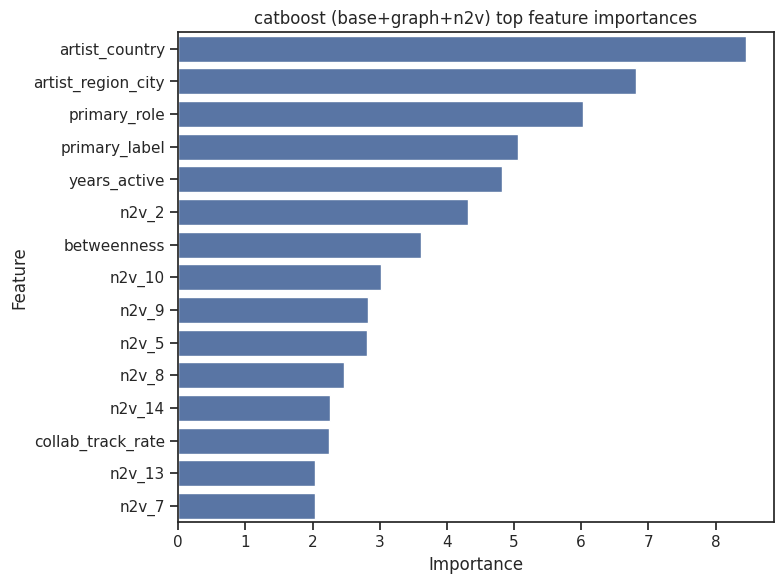

In [45]:
if best_row["model"] == "catboost":
    importances = pd.Series(
        best_model.get_feature_importance(type="FeatureImportance"),
        index=feature_names,
    )
else:
    importances = pd.Series(best_model.feature_importances_, index=feature_names)

importances = importances.sort_values(ascending=False)
display(importances.to_frame("importance"))

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values[:15], y=importances.index[:15])
plt.title(f"{best_row['model']} ({best_row['feature_set']}) top feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## SHAP summary plot for the best model

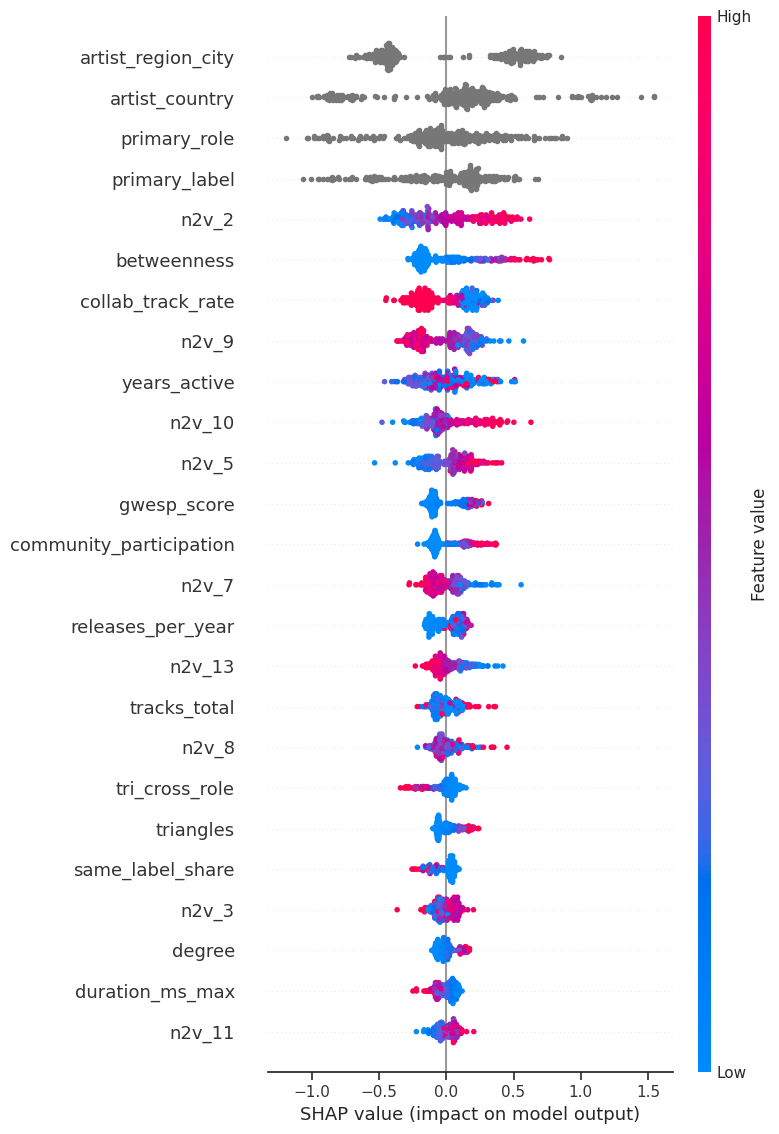

In [46]:
sample = best_features.sample(
    n=min(300, len(best_features)), random_state=RANDOM_STATE
)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    features=sample,
    feature_names=feature_names,
    show=False,
    max_display=25,
)
plt.tight_layout()
plt.show()
